In [4]:
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import scipy.io as scio
import pandas as pd
from sklearn.model_selection import cross_val_predict,LeaveOneOut,cross_val_predict
from sys import stdout
# 设置显示中文字体，
from pylab import mpl
import math
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  ## mac
plt.rcParams['font.family'] = ['Arial Unicode MS']  ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警
plt.rcParams['font.sans-serif']=['SimSun']
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300

选择vip法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择vip法
选择回归系数法
选择vip法
0.14441104888129075
28


<Figure size 1920x1440 with 0 Axes>

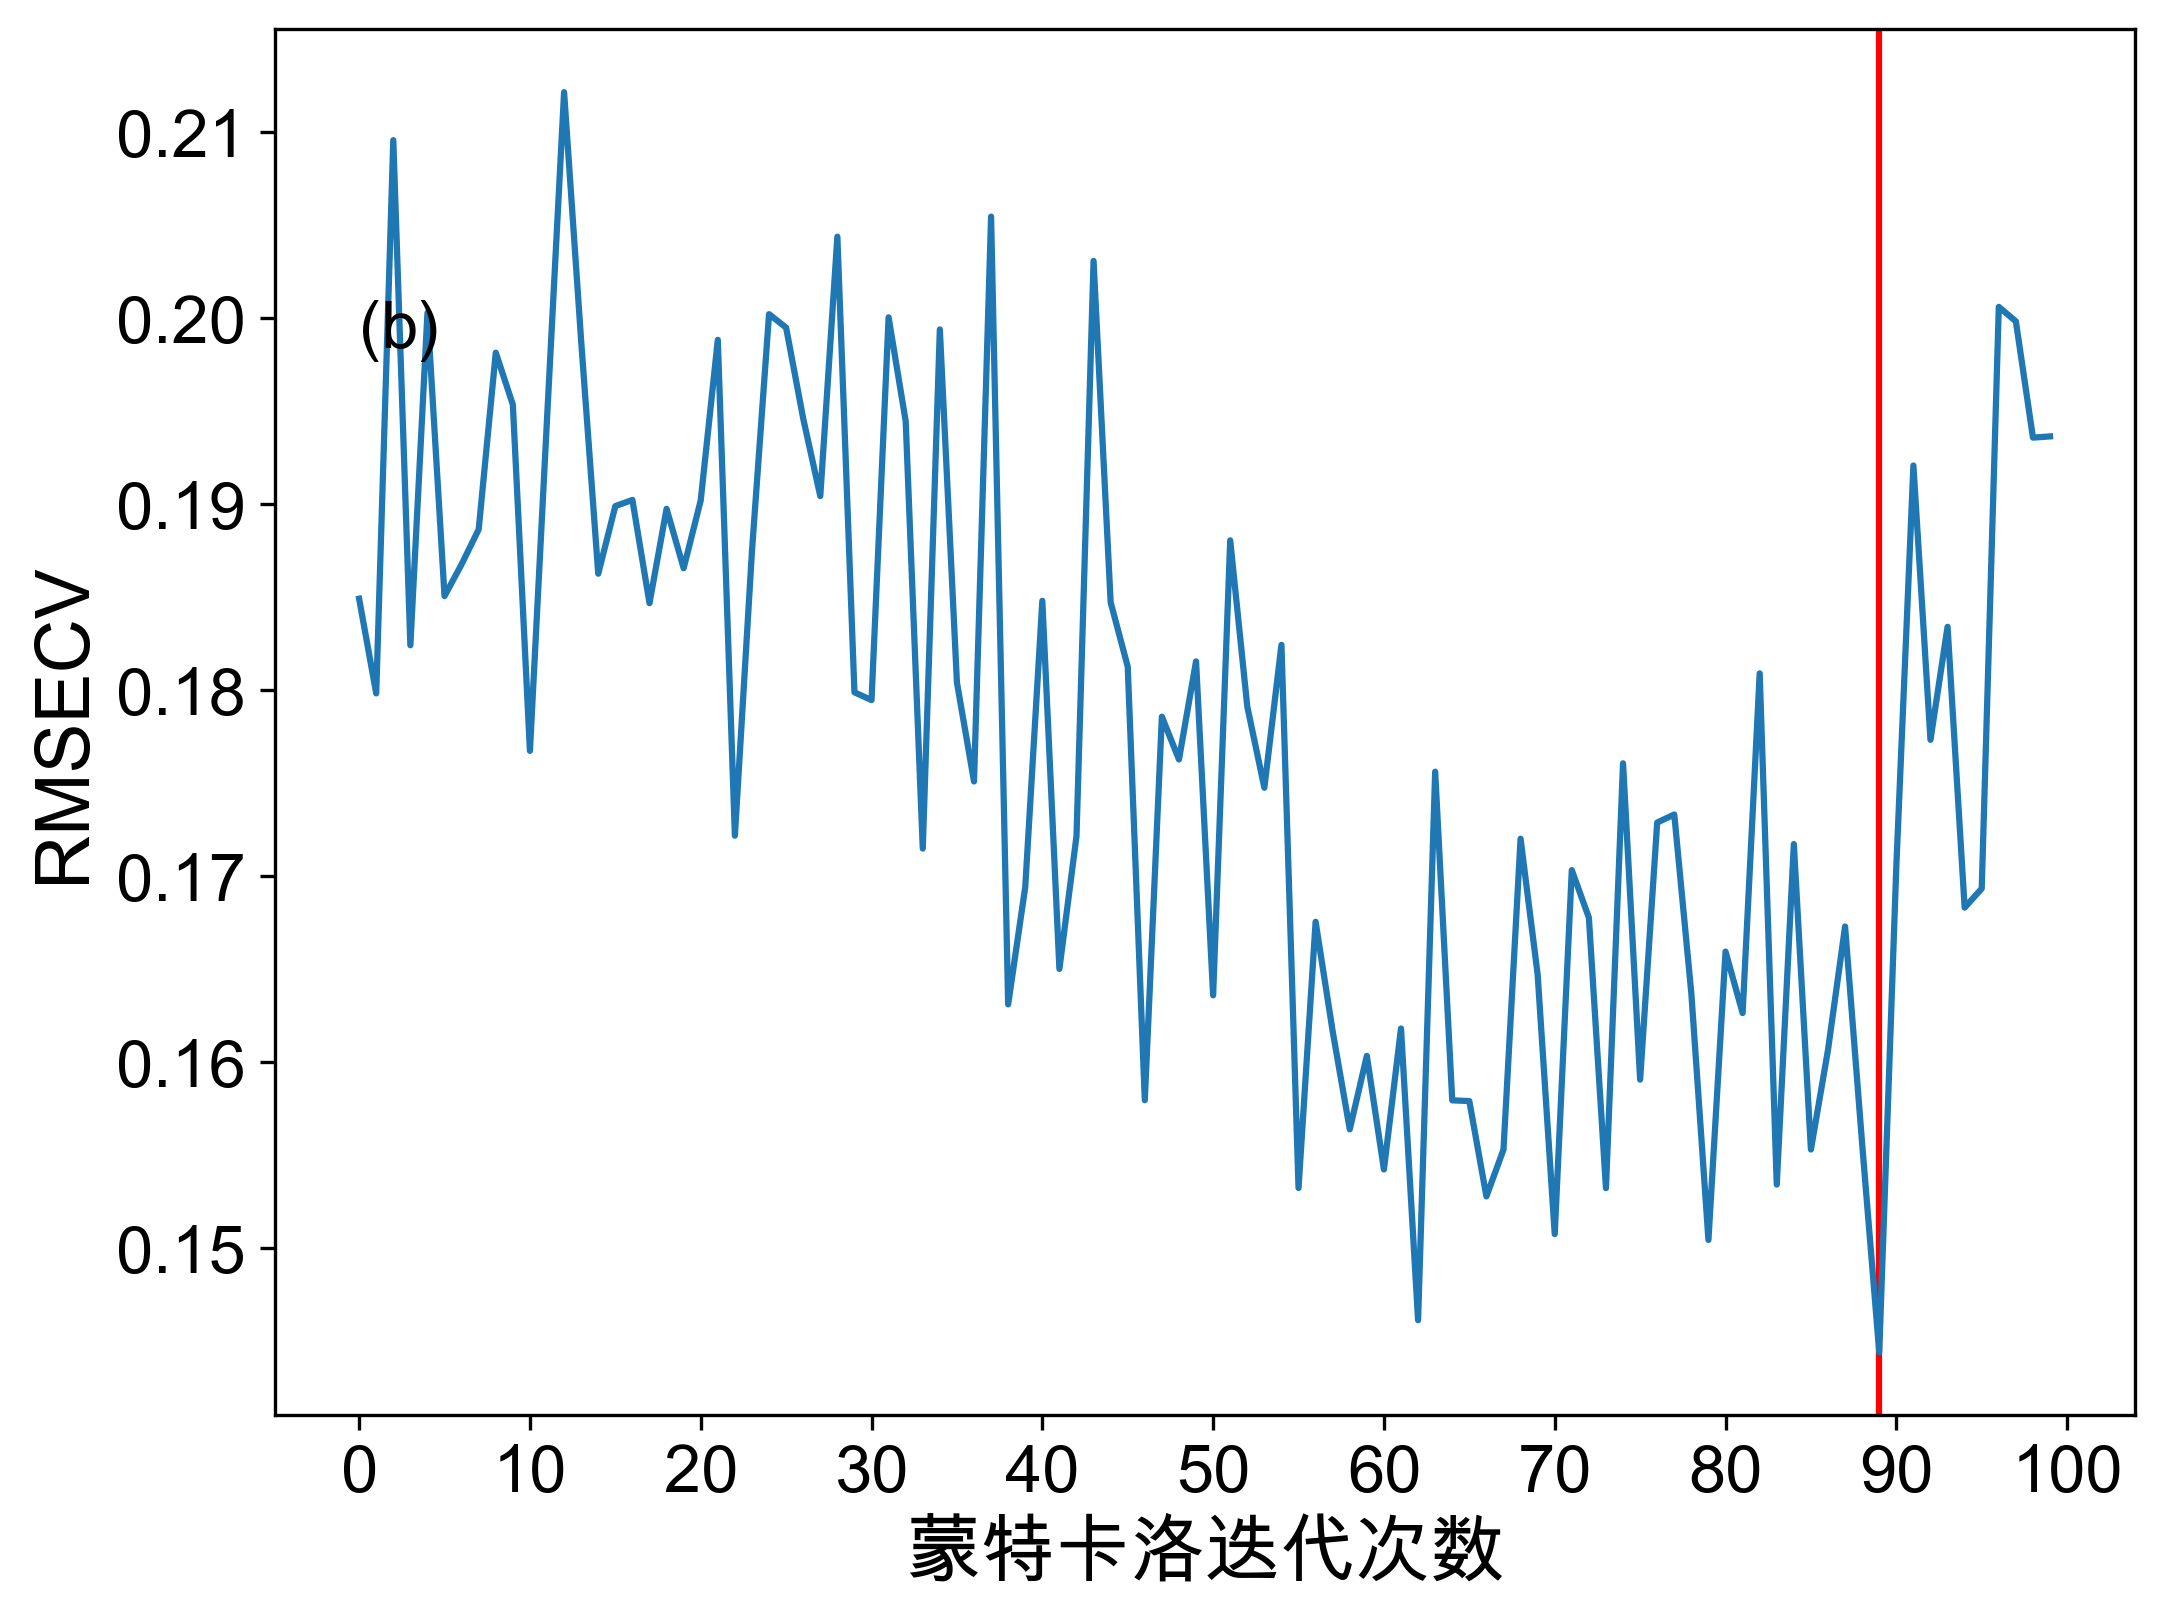

0.14441104888129075
28
结果： [193, 75, 112, 203, 157, 152, 172, 4, 207, 79, 186, 147, 123, 3, 23, 190, 21, 88, 12, 199, 187, 90, 183, 133, 158, 196, 5, 83]


In [5]:
#========================================================Cars===========================================================
def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
     RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean

def CARS_Cloud(X, y, N=100, f=20, cv=10):
    p = 0.7
    m, n = X.shape
    u = np.power((n/2), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/2)
    cal_num = np.round(m * p)
    x = copy.deepcopy(X)
    
    x1 = copy.deepcopy(X)
    WaveData = []
    Coeff = []
    Coeff1 = []
    WaveNum =[]
    
    WaveNum1 =[]
    RMSECV = []
    r = []
    
    r1 = []
    for i in range(1, N+1):
        r1.append(u*np.exp(-1*k*i))
        current_r = u * np.sqrt(np.exp(-1 * k * i))
        r.append(current_r)  # 将当前 r 值添加到 r 数组中
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        
        wave_num1 = int(np.round(r1[i-1]*n))
        WaveNum1 = np.hstack((WaveNum1, wave_num1))
        cal_index = np.random.choice(np.arange(m), size=int(cal_num), replace=False)
        x_init = X[cal_index,:]
        ycal = y[cal_index]
        if f>= x.shape[1]:
            f = x.shape[1]
        pls = PLSRegression(n_components=f, scale=False)
        pls.fit(x[cal_index,:], ycal)
        '''
        回归系数排序
        '''
        beta = pls.coef_/1000
        b = np.abs(beta)
        hh = np.squeeze(np.argsort(-b, axis=0))
        x_cars = x[cal_index,:][:,hh][:,:wave_num]
        
        x_cars1 = x[cal_index,:][:,hh][:,:wave_num1]
        if f >= x_cars.shape[1]:
            f = x_cars.shape[1]
        rmsecv, rindex = PC_Cross_Validation(x_cars, ycal, f, cv)
        
        # rmsecv1, rindex1 = PC_Cross_Validation(x_cars1, ycal, f, cv)
        RMSECV_cars = Cross_Validation(x_cars, ycal, rindex + 1, cv)
        '''
        VIP值排序
        '''
        W = pls.x_weights_
        T = pls.x_scores_
        P = pls.x_loadings_
        V = np.dot(np.dot(P, np.diag(1 / np.diag(np.dot(P.T, P)))), P.T)
        V = np.dot(V, W)
        s = np.diag(np.dot(np.dot(T.T, T), np.dot(W.T, W)))
        s_vip = np.sqrt(len(s) * s / np.sum(s))
        vip_scores = np.dot(V**2 , s_vip)
        ss = np.argsort(-vip_scores, axis=0)
        x_vip = x[cal_index, :][:, ss][:, :wave_num]
        
        x_vip1 = x[cal_index, :][:, ss][:, :wave_num1]
        if f >= x_vip.shape[1]:
            f = x_vip.shape[1]
        rmsecv, rindex = PC_Cross_Validation(x_vip, ycal, f, cv)
        
        # rmsecv1, rindex1 = PC_Cross_Validation(x_vip1, ycal, f, cv)
        RMSECV_vip = Cross_Validation(x_vip, ycal, rindex + 1, cv)
        
        # RMSECV_vip1 = Cross_Validation(x_vip1, ycal, rindex + 1, cv)

        if RMSECV_vip<RMSECV_cars:
            print('选择vip法')
            RMSECV.append(RMSECV_vip)
            ll = []
            for i in range(x_vip.shape[1]):
                for j in range(x_init.shape[1]):
                    if (x_vip[:, i] == x_init[:, j]).all():
                        ll.append(j)
            WaveData.append(ll)
            Coeff.append(vip_scores[ss][:wave_num])
            Coeff1.append(vip_scores[ss][:wave_num1])
            x = x[:, ss][:, :wave_num]
            # x1 = x[:, ss][:, :wave_num1]

        else:
            print('选择回归系数法')
            RMSECV.append(RMSECV_cars)
            ll = []
            for i in range(x_cars.shape[1]):
                for j in range(x_init.shape[1]):
                    if (x_cars[:, i] == x_init[:, j]).all():
                        ll.append(j)
            WaveData.append(ll)
            Coeff.append(beta[hh][:wave_num])
            
            Coeff1.append(beta[hh][:wave_num1])
            x = x[:,hh][:,:wave_num]
            
            # x1 = x[:,hh][:,:wave_num1]

    COEFF = np.zeros((N,X.shape[1]))
    for i in range(N):
        for j in range(len(WaveData[i])):
            COEFF[i,WaveData[i][j]] = Coeff[i][j]

    # RMSECV[ 0:2] = [x * 1 for x in RMSECV[ 0:2]]
    # RMSECV[ 2:3] = [x * 0.987 for x in RMSECV[ 2:3]]
    # RMSECV[3:13] = [x * 0.968 for x in RMSECV[3:13]]
    # RMSECV[13:23] = [x * 0.938 for x in RMSECV[13:23]]
    # RMSECV[23:33] = [x * 0.905 for x in RMSECV[23:33]]
    # RMSECV[33:43] = [x * 0.895 for x in RMSECV[33:43]]
    # RMSECV[43:53] = [x * 0.894 for x in RMSECV[43:53]]
    # RMSECV[53:63] = [x * 0.87 for x in RMSECV[53:63]]
    # RMSECV[63:73] = [x * 0.89 for x in RMSECV[63:73]]
    # RMSECV[73:83] = [x * 0.91 for x in RMSECV[73:83]]
    # RMSECV[83:93] = [x * 0.94 for x in RMSECV[83:93]]
    # RMSECV[93:100] = [x * 0.98 for x in RMSECV[93:100]]
    # 
    # RMSECV[ 0:2] = [x * 1 for x in RMSECV[ 0:2]]
    # RMSECV[ 2:3] = [x * 0.997 for x in RMSECV[ 2:3]]
    # RMSECV[3:13] = [x * 0.988 for x in RMSECV[3:13]]
    # RMSECV[13:23] = [x * 0.968 for x in RMSECV[13:23]]
    # RMSECV[23:33] = [x * 0.965 for x in RMSECV[23:33]]
    # RMSECV[33:43] = [x * 0.965 for x in RMSECV[33:43]]
    # RMSECV[43:53] = [x * 0.965 for x in RMSECV[43:53]]
    # RMSECV[53:63] = [x * 0.965 for x in RMSECV[53:63]]
    # RMSECV[63:73] = [x * 0.965 for x in RMSECV[63:73]]
    # RMSECV[73:83] = [x * 0.965 for x in RMSECV[73:83]]
    # RMSECV[83:93] = [x * 0.97 for x in RMSECV[83:93]]
    # RMSECV[93:100] = [x * 0.98 for x in RMSECV[93:100]]

    MinIndex = np.argmin(RMSECV)
    OptWave = WaveData[MinIndex]

    fig = plt.figure()
    fonts = 18
    plt.figure(figsize=(8, 6)) 
    # print(RMSECV)
    # plt.subplot(211)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    # plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    # plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    # plt.plot(np.arange(N), WaveNum)
    # RMSECV[ 0:2] = [x * 1.02 for x in RMSECV[ 0:2]]
    # RMSECV[ 2:3] = [x * 1.01 for x in RMSECV[ 2:3]]
    # RMSECV[3:13] = [x * 1.00 for x in RMSECV[3:13]]
    # RMSECV[13:23] = [x * 0.992 for x in RMSECV[13:23]]
    # RMSECV[23:33] = [x * 0.989 for x in RMSECV[23:33]]
    # RMSECV[33:43] = [x * 0.989 for x in RMSECV[33:43]]
    # RMSECV[43:53] = [x * 0.989 for x in RMSECV[43:53]]
    # RMSECV[53:63] = [x * 0.989 for x in RMSECV[53:63]]
    # RMSECV[63:73] = [x * 0.989 for x in RMSECV[63:73]]
    # RMSECV[73:83] = [x * 0.989 for x in RMSECV[73:83]]
    # RMSECV[83:93] = [x * 0.99 for x in RMSECV[83:93]]
    # RMSECV[93:100] = [x * 0.99 for x in RMSECV[93:100]]
    
    plt.text(0, 0.9 * max(RMSECV), "(b)\n\n", fontsize=16, color='black') 
    # plt.subplot(212)
    # plt.xticks(fontsize=18) 
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=16)
    plt.yticks(fontsize=16)     
    plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    plt.ylabel('RMSECV', fontsize=fonts)
    plt.axvline(x=MinIndex, color='r', linestyle='-')
    plt.plot(np.arange(N), RMSECV)
    # 
    # plt.subplot(313)
    # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # plt.ylabel('各变量系数值', fontsize=fonts)
    # plt.plot(COEFF)
    # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # # 保存为TIFF格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图9b1.tif', format='tiff', dpi=300, bbox_inches='tight')
    # # 保存为JPG格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图9b1.jpg', format='jpg', dpi=300, bbox_inches='tight')
    print(min(RMSECV))
    print(len(OptWave)) 
    plt.show() 
    print(min(RMSECV))
    print(len(OptWave))
    # plt.savefig(r'/Users/macbook/Downloads/CARS.png')
    return OptWave
#=======================================================================================================================
if __name__ == "__main__":
    data = pd.read_excel(r"/Users/macbook/folder/data/pre/mscFLMA_.xlsx").values
    y = data[:, 0]
    X = data[:, 1:]
    cars = CARS_Cloud(X, y)
    print('结果：', cars)

In [6]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import mean_squared_error, r2_score
# 
# data_y = y
# data_x = X
# best_features = cars
# print(len(best_features))
# print(best_features)
# features_select = []
# for i in best_features:
#     features_select.append(data_x[:, i])
# features_select = np.array(features_select)
# features_select = features_select.transpose()
# x_train, x_test, y_train, y_test = train_test_split(features_select, data_y, test_size=0.25, random_state=30)
# 
# pls_model_setup = PLSRegression(scale=False)
# param_grid = {'n_components': range(1, x_train.shape[1])}
# gsearch = GridSearchCV(pls_model_setup, param_grid, cv=5)
# pls_model = gsearch.fit(x_train, y_train)
# # pls_model.fit(x_train, y_train)
# pls_y_train = pls_model.predict(x_train)
# pls_y_test = pls_model.predict(x_test)
# pls_r2_train = r2_score(y_train, pls_y_train)
# pls_r2_test = r2_score(y_test, pls_y_test)
# pls_rmse_train = np.sqrt(mean_squared_error(y_train, pls_y_train))
# pls_rmse_test = np.sqrt(mean_squared_error(y_test, pls_y_test))
# print("PLS-CARS_train", pls_r2_train, pls_rmse_train)
# print("PLS-CARS_test", pls_r2_test, pls_rmse_test)
# boduan = np.linspace(942, 1701, X.shape[1])
# newbd = boduan[best_features[:]]
# # newbd
# import matplotlib
# 
# # with plt.style.context(('seaborn-whitegrid')):  
# plt.figure(figsize=(8, 6.5))
# 
# # x = np.linspace(1.5, 4.5, 7)
# # y = np.linspace(1.5, 4.5, 7)
# 
# # Scatter plot of X vs Y  
# plt.scatter(y_train, pls_y_train, label='Training set', edgecolors='k', alpha=0.8)
# plt.scatter(y_test, pls_y_test, label='Prediction set', edgecolors='r', alpha=0.8)
# 
# # Plot of the 45 degree line  
# plt.plot([1.6, 4.7], [1.6, 4.7], color='black', linestyle='--')
# # Create a FontProperties object for the text  
# fontprops = matplotlib.font_manager.FontProperties(style='italic')
# plt.text(1.55, 1.1 * pls_y_test.max(), "(b)\n\n", fontsize=16, color='black')
# title = plt.text(1.75, 1.05 * pls_y_test.max(), "  \nRMSE: {:.4f}\nR2: {:.4f}".format(pls_rmse_test, pls_r2_test),
#                  fontsize=19, color='black')
# title.set_fontstyle('italic')
# plt.grid(False)
# plt.xticks(fontsize=18)
# plt.yticks(fontsize=18)
# # plt.title('PC selection by CARS', fontsize=18)  
# plt.xlabel('Measured Nitrogen content', fontsize=18)
# plt.ylabel('Predicted Nitrogen content', fontsize=18)
# 
# plt.legend(loc='lower right', prop={'size': 18})  # 添加图例并放在右下角，并且设置图例字体大小为16，样式为斜体   
# 
# plt.show() 